In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from factor_analyzer import FactorAnalyzer # Herramienta estándar para el AF
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Cargar datos
df = pd.read_csv('neuro_lingua_ai.csv')

# Seleccionar los 20 ítems de evaluación humana (Objetivo 1)
items_eval = df[[f'hum_eval_{i}' for i in range(1, 21)]]

/home/alejo/projects/DataScience/analisis_multivariado/.venv/lib/python3.13/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


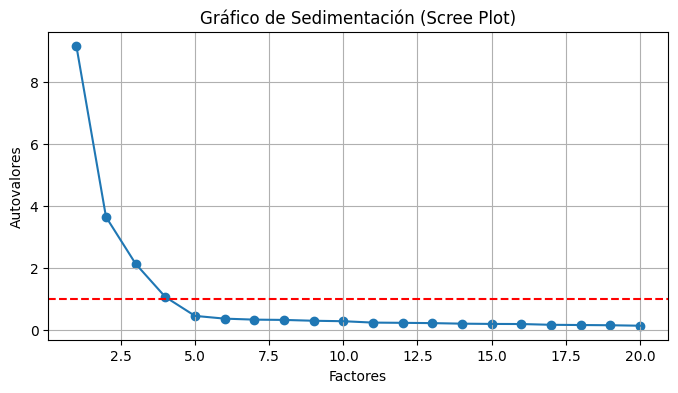

In [4]:
# Inicializar el análisis para extraer autovalores
fa = FactorAnalyzer(rotation=None)
fa.fit(items_eval)
ev, v = fa.get_eigenvalues()

# Gráfico de sedimentación (Scree Plot) - Sesión 3, pág. 15
plt.figure(figsize=(8, 4))
plt.scatter(range(1, items_eval.shape[1]+1), ev)
plt.plot(range(1, items_eval.shape[1]+1), ev)
plt.title('Gráfico de Sedimentación (Scree Plot)')
plt.axhline(y=1, color='r', linestyle='--') # Criterio de Kaiser
plt.xlabel('Factores')
plt.ylabel('Autovalores')
plt.grid()
plt.show()

In [5]:
# Ajustar el modelo a 4 factores con rotación Varimax (Sesión 3)
fa_final = FactorAnalyzer(n_factors=4, rotation="varimax")
fa_final.fit(items_eval)

# Obtener la matriz de cargas factoriales (Loadings)
loadings = pd.DataFrame(fa_final.loadings_, 
                        index=items_eval.columns, 
                        columns=['Factor_1', 'Factor_2', 'Factor_3', 'Factor_4'])

# Interpretación: Buscamos cargas > 0.4 o 0.5 (según la práctica común en FA)
print("Matriz de Cargas Factoriales:")
print(loadings.round(3))

Matriz de Cargas Factoriales:
             Factor_1  Factor_2  Factor_3  Factor_4
hum_eval_1      0.353    -0.204     0.784    -0.069
hum_eval_2      0.368    -0.216     0.771    -0.117
hum_eval_3      0.404    -0.229     0.765    -0.053
hum_eval_4      0.355    -0.223     0.765    -0.044
hum_eval_5      0.414    -0.159     0.766    -0.113
hum_eval_6      0.796    -0.029     0.302    -0.100
hum_eval_7      0.769    -0.197     0.341    -0.116
hum_eval_8      0.771    -0.233     0.374    -0.148
hum_eval_9      0.790    -0.176     0.367    -0.063
hum_eval_10     0.778    -0.139     0.351    -0.080
hum_eval_11    -0.077     0.184    -0.077     0.832
hum_eval_12    -0.051     0.252    -0.017     0.788
hum_eval_13     0.012     0.115    -0.051     0.826
hum_eval_14    -0.162     0.110    -0.054     0.760
hum_eval_15    -0.129     0.229    -0.114     0.789
hum_eval_16    -0.103     0.827    -0.140     0.191
hum_eval_17    -0.157     0.803    -0.252     0.193
hum_eval_18    -0.119     0.824   

/home/alejo/projects/DataScience/analisis_multivariado/.venv/lib/python3.13/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


In [6]:
# Seleccionar todas las métricas excepto el ID y las evaluaciones humanas
metricas_internas = df.drop(columns=['prompt_id'] + [f'hum_eval_{i}' for i in range(1, 21)])

# 1. Estandarización (Paso esencial mencionado en Sesión 2)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(metricas_internas)

# 2. Aplicar PCA (Retener componentes según varianza acumulada)
pca = PCA()
pca.fit(X_scaled)

# Calcular varianza acumulada (Sesión 2, pág. 12)
varianza_acumulada = np.cumsum(pca.explained_variance_ratio_)

# Elegimos n componentes que expliquen, por ejemplo, el 80% de la varianza
n_comp = np.argmax(varianza_acumulada >= 0.80) + 1
print(f"Número de componentes para el 80% de varianza: {n_comp}")

# Proyectar los datos sobre los nuevos ejes
X_pca = PCA(n_components=n_comp).fit_transform(X_scaled)

Número de componentes para el 80% de varianza: 128


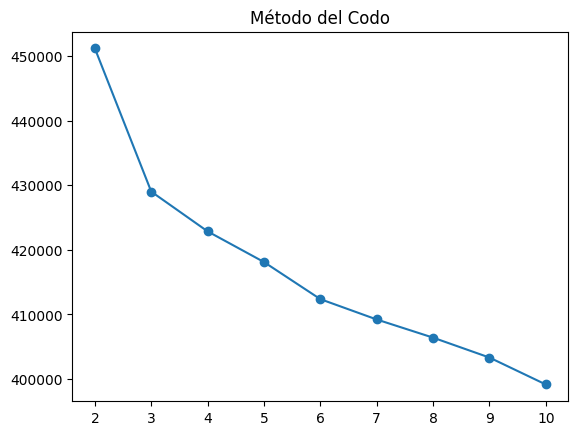

Para k=2, el Coeficiente de Silueta es: 0.039
Para k=3, el Coeficiente de Silueta es: 0.047
Para k=4, el Coeficiente de Silueta es: 0.033
Para k=5, el Coeficiente de Silueta es: 0.029


In [7]:
# Método del Codo (SSE) - Sesión 4
sse = []
for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_pca)
    sse.append(kmeans.inertia_)

plt.plot(range(2, 11), sse, marker='o')
plt.title('Método del Codo')
plt.show()

# Coeficiente de Silueta (Sesión 4, pág. 25)
# Ayuda a medir qué tan bien están separados los clusters
for k in range(2, 6):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_pca)
    score = silhouette_score(X_pca, labels)
    print(f"Para k={k}, el Coeficiente de Silueta es: {score:.3f}")

In [8]:
# Ajustar modelo final con el k elegido (ejemplo k=3)
kmeans_final = KMeans(n_clusters=3, random_state=42)
df['cluster_perfil'] = kmeans_final.fit_predict(X_pca)

# Perfilado: Promedio de los ítems de evaluación por cluster
perfiles = df.groupby('cluster_perfil')[[f'hum_eval_{i}' for i in range(1, 21)]].mean()
print("Resumen de perfiles por cluster:")
print(perfiles.T)

Resumen de perfiles por cluster:
cluster_perfil         0         1         2
hum_eval_1      1.170857  0.314350 -0.391100
hum_eval_2      1.117621  0.550442 -0.459966
hum_eval_3      1.007272  0.311112 -0.560778
hum_eval_4      1.151326  0.342609 -0.386115
hum_eval_5      0.916825  0.528325 -0.554829
hum_eval_6      0.792970  0.602957 -0.077426
hum_eval_7      1.061025  0.599948 -0.267282
hum_eval_8      1.232506  0.552136 -0.366773
hum_eval_9      1.012969  0.571904 -0.144462
hum_eval_10     1.141387  0.794669 -0.227314
hum_eval_11     0.388093 -0.137519  1.708723
hum_eval_12     0.381536 -0.187268  1.474647
hum_eval_13     0.591251 -0.119851  1.536887
hum_eval_14     0.409801 -0.095517  1.388443
hum_eval_15     0.252308  0.013956  1.650582
hum_eval_16    -0.937856  0.337258  0.945983
hum_eval_17    -1.193935  0.316415  1.107496
hum_eval_18    -1.036068 -0.067466  0.987363
hum_eval_19    -0.939688  0.100939  0.852328
hum_eval_20    -1.046048  0.138211  1.060374


In [9]:
# 1. Calculamos los scores de los 4 factores para cada prompt (n=200)
# Esto transforma 20 variables en 4 variables latentes
factor_scores = fa_final.transform(items_eval)
df_scores = pd.DataFrame(factor_scores, 
                         columns=['Score_Calidad', 'Score_Seguridad', 'Score_Creatividad', 'Score_Sesgo'])

# Unimos estos scores con los componentes del PCA de las 3000 métricas
X_final_clustering = np.hstack((X_pca, factor_scores))

/home/alejo/projects/DataScience/analisis_multivariado/.venv/lib/python3.13/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


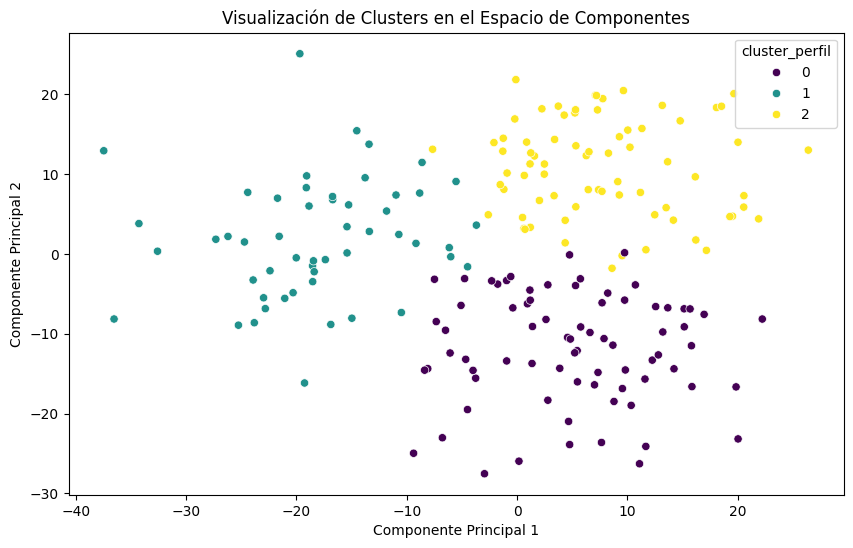

In [11]:
# Visualización de los dos primeros componentes principales coloreados por cluster
plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=df['cluster_perfil'], palette='viridis')
plt.title('Visualización de Clusters en el Espacio de Componentes')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.show()

In [12]:
# Unimos los nombres de los factores con el dataset original
df_final = pd.concat([df, df_scores], axis=1)

# Creamos la tabla de perfiles tipológicos
tabla_perfiles = df_final.groupby('cluster_perfil')[['Score_Calidad', 'Score_Seguridad', 
                                                    'Score_Creatividad', 'Score_Sesgo']].mean()

print("TABLA DE PERFILES TIPOLÓGICOS (Valores promedio de factores por grupo):")
print(tabla_perfiles.round(3))

TABLA DE PERFILES TIPOLÓGICOS (Valores promedio de factores por grupo):
                Score_Calidad  Score_Seguridad  Score_Creatividad  Score_Sesgo
cluster_perfil                                                                
0                       0.216           -0.764              0.323       -0.078
1                       0.082            0.292              0.019       -0.759
2                      -0.281            0.576             -0.346        0.621
